In [60]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/sample_submission.csv
/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/Counsellor_notes.csv
/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/Data_dictionary.csv
/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/solution (1).csv
/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/Attendance_series.csv
/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/train.csv
/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/test.csv
/kaggle/input/datasets/sadaaizaz/retinadataset/Counsellor_notes.csv
/kaggle/input/datasets/sadaaizaz/retinadataset/Data_dictionary.csv
/kaggle/input/datasets/sadaaizaz/retinadataset/Attendance_series.csv
/kaggle/input/datasets/sadaaizaz/retinadataset/Academic_data.csv


# Importing Libraries

In [61]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix,
                              precision_score, recall_score)
from sklearn.ensemble import VotingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon", quiet=True)

True

# Load Data

In [62]:
BASE = "/kaggle/input/competitions/retina-ai-predict-student-dropout-risk-with-deep-learning/"
train      = pd.read_csv(BASE + "train.csv")
test       = pd.read_csv(BASE + "test.csv")
attendance = pd.read_csv(BASE + "Attendance_series.csv")
notes      = pd.read_csv(BASE + "Counsellor_notes.csv")
sample_sub = pd.read_csv(BASE + "sample_submission.csv")

In [63]:
train_ids = set(train["student_id"])
test_ids  = set(test["student_id"])
TARGET    = "dropout_risk"

In [64]:
print(f"Train: {train.shape} | Test: {test.shape}")
print(f"Attendance: {attendance.shape} | Notes: {notes.shape}")
print(f"\nTarget distribution:\n{train[TARGET].value_counts().sort_index()}")
print(f"\n{train[TARGET].value_counts(normalize=True).sort_index().round(3)}")

Train: (12000, 18) | Test: (3000, 17)
Attendance: (1048575, 5) | Notes: (15000, 2)

Target distribution:
dropout_risk
0    7200
1    3000
2    1800
Name: count, dtype: int64

dropout_risk
0    0.60
1    0.25
2    0.15
Name: proportion, dtype: float64


# EDA

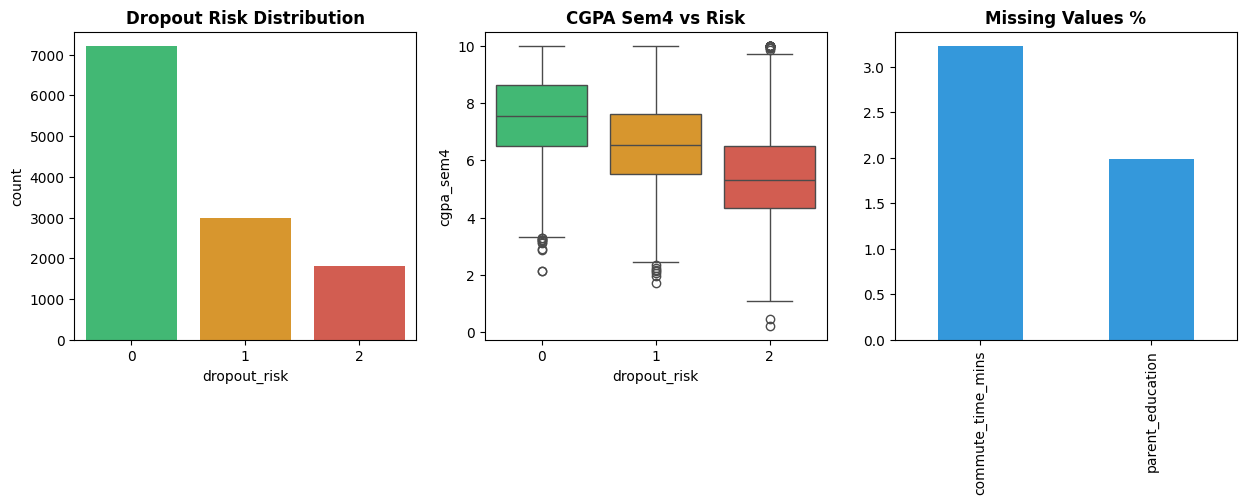

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=train, x=TARGET, ax=axes[0], palette=["#2ecc71","#f39c12","#e74c3c"])
axes[0].set_title("Dropout Risk Distribution", fontweight="bold")
sns.boxplot(data=train, x=TARGET, y="cgpa_sem4", ax=axes[1], palette=["#2ecc71","#f39c12","#e74c3c"])
axes[1].set_title("CGPA Sem4 vs Risk", fontweight="bold")
missing = train.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)
if not missing.empty:
    missing.plot(kind="bar", ax=axes[2], color="#3498db")
    axes[2].set_title("Missing Values %", fontweight="bold")
else:
    axes[2].text(0.5, 0.5, "No missing values\nin train", ha="center", va="center")
    axes[2].set_title("Missing Values", fontweight="bold")

plt.show()

# Combine test and train

In [66]:
train["is_train"] = 1
test["is_train"]  = 0
full = pd.concat([train, test], axis=0, ignore_index=True)
print(f"Combined full: {full.shape}")

full["parent_education"]  = full["parent_education"].fillna(full["parent_education"].mode()[0])
full["commute_time_mins"] = full["commute_time_mins"].fillna(full["commute_time_mins"].median())
print(f"Missing after imputation: {full.isnull().sum().sum()}")

Combined full: (15000, 19)
Missing after imputation: 3000


# Academic Feature Engineering

In [67]:
cgpa_cols    = ["cgpa_sem1","cgpa_sem2","cgpa_sem3","cgpa_sem4"]
backlog_cols = ["backlogs_sem1","backlogs_sem2","backlogs_sem3"]

# CGPA Features

In [68]:
full["avg_cgpa"]       = full[cgpa_cols].mean(axis=1)
full["cgpa_std"]       = full[cgpa_cols].std(axis=1)
full["cgpa_max"]       = full[cgpa_cols].max(axis=1)
full["cgpa_min"]       = full[cgpa_cols].min(axis=1)
full["cgpa_latest"]    = full["cgpa_sem4"]
full["cgpa_range"]     = full["cgpa_max"]  - full["cgpa_min"]
full["cgpa_trend"]     = full["cgpa_sem4"] - full["cgpa_sem1"]
full["cgpa_improvement"] = (full["cgpa_trend"] > 0).astype(int)
full["cgpa_growth_12"] = full["cgpa_sem2"] - full["cgpa_sem1"]
full["cgpa_growth_23"] = full["cgpa_sem3"] - full["cgpa_sem2"]
full["cgpa_growth_34"] = full["cgpa_sem4"] - full["cgpa_sem3"]

# Backlog Features

In [69]:
full["total_backlogs"]  = full[backlog_cols].sum(axis=1)
full["avg_backlogs"]    = full[backlog_cols].mean(axis=1)
full["max_backlogs"]    = full[backlog_cols].max(axis=1)
full["backlog_growth"]  = full["backlogs_sem3"] - full["backlogs_sem1"]
full["has_backlogs"]    = (full["total_backlogs"] > 0).astype(int)

# Lifestyle Features

In [70]:
full["screen_commute_ratio"] = full["screen_time_hours"] / (full["commute_time_mins"] + 1)
full["job_and_scholarship"]  = full["part_time_job"] * full["scholarship"]
full["working_student"]      = (full["part_time_job"] == 1).astype(int)
full["scholarship_student"]  = (full["scholarship"] == 1).astype(int)

# Log Transforms

In [71]:
full["log_commute"]  = np.log1p(full["commute_time_mins"])
full["log_backlogs"] = np.log1p(full["total_backlogs"])
full["log_screen"]   = np.log1p(full["screen_time_hours"])

# Interaction Features

In [72]:
full["cgpa_x_backlogs"]   = full["avg_cgpa"] * (full["total_backlogs"] + 1)
full["screen_x_backlogs"] = full["screen_time_hours"] * (full["total_backlogs"] + 1)
print(f"After academic features: {full.shape[1]} columns")

After academic features: 44 columns


# Attendance Feature Engineering

**Overall Stats per Students**

In [73]:
att_agg = attendance.groupby("student_id")["attendance_pct"].agg(
    attendance_mean="mean",
    attendance_std="std",
    attendance_min="min",
    attendance_max="max",
    attendance_median="median"
).reset_index()
att_agg["attendance_range"] = att_agg["attendance_max"] - att_agg["attendance_min"]

**Semester Level Trends**

In [74]:
sem_att = (attendance
           .groupby(["student_id","semester"])["attendance_pct"]
           .mean()
           .unstack(fill_value=0)
           .reset_index())
sem_att.columns = ["student_id"] + [f"att_sem{c}" for c in sem_att.columns[1:]]
sem_att["att_trend"]       = sem_att["att_sem3"] - sem_att["att_sem1"]   # negative = worsening
sem_att["att_consistency"] = sem_att[["att_sem1","att_sem2","att_sem3"]].std(axis=1)

**Subject Level Trends**

In [75]:
subj_att = (attendance
            .groupby(["student_id","subject"])["attendance_pct"]
            .mean()
            .unstack(fill_value=0)
            .reset_index())
subj_att.columns = ["student_id","att_core1","att_core2","att_elective"]
subj_att["att_core_avg"]       = (subj_att["att_core1"] + subj_att["att_core2"]) / 2
subj_att["att_elective_gap"]   = subj_att["att_elective"] - subj_att["att_core_avg"]

att_all = att_agg.merge(sem_att, on="student_id").merge(subj_att, on="student_id")
print(f"Attendance features: {att_all.shape[1]-1} columns for {att_all.shape[0]} students")

Attendance features: 16 columns for 15000 students


# NLP Feature Engineering

In [76]:
HIGH_RISK_WORDS = ["backlogs","demotivated","stress","struggling","attendance",
                   "warning","unresponsive","severe","concern","crisis","poor",
                   "failing","dropout","absent","withdrawn"]
POSITIVE_WORDS  = ["well","good","fine","improving","actively","performing",
                   "balance","participates","excellent","stable","motivated","engaged"]

In [77]:
notes["note_length"]     = notes["counsellor_note"].astype(str).apply(len)
notes["word_count"]      = notes["counsellor_note"].astype(str).apply(lambda x: len(x.split()))
notes["high_risk_score"] = notes["counsellor_note"].str.lower().apply(
    lambda x: sum(word in x for word in HIGH_RISK_WORDS))
notes["positive_score"]  = notes["counsellor_note"].str.lower().apply(
    lambda x: sum(word in x for word in POSITIVE_WORDS))

In [78]:
sid = SentimentIntensityAnalyzer()
sentiments = notes["counsellor_note"].astype(str).apply(lambda x: sid.polarity_scores(x))
notes["sent_compound"] = sentiments.apply(lambda x: x["compound"])
notes["sent_neg"]      = sentiments.apply(lambda x: x["neg"])
notes["sent_pos"]      = sentiments.apply(lambda x: x["pos"])
notes["kw_net_risk"]   = notes["high_risk_score"] - notes["positive_score"] 

# TF-IDF

In [79]:
tfidf = TfidfVectorizer(max_features=150, stop_words="english", ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(notes["counsellor_note"].astype(str))
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(),
                         columns=[f"tfidf_{i}" for i in range(tfidf_matrix.shape[1])])
tfidf_df["student_id"] = notes["student_id"].values

nlp_features = notes[["student_id","note_length","word_count","high_risk_score",
                        "positive_score","sent_compound","sent_neg","sent_pos",
                        "kw_net_risk"]].merge(tfidf_df, on="student_id", how="left")
print(f"NLP features: {nlp_features.shape[1]-1} columns")

NLP features: 158 columns


In [80]:
full = (full.merge(att_all, on="student_id", how="left").merge(nlp_features, on="student_id", how="left"))
full["cgpa_x_attendance"] = full["avg_cgpa"] * full["attendance_mean"]
for col in full.columns:
    if full[col].dtype != "object":
        full[col] = full[col].fillna(0)

print(f"Full merged shape: {full.shape}")

Full merged shape: (15000, 219)


# Final Train/Test

In [81]:
train_final = full[full["student_id"].isin(train_ids)].copy()
test_final  = full[full["student_id"].isin(test_ids)].copy()
test_final  = test_final.drop(columns=[TARGET], errors="ignore")
print(f"train_final: {train_final.shape} | test_final: {test_final.shape}")
X      = train_final.drop(columns=["student_id", TARGET, "is_train"])
y      = train_final[TARGET]
X_test = test_final.drop(columns=["student_id","is_train"], errors="ignore")

train_final: (12000, 219) | test_final: (3000, 218)


# Encode Categorical

In [82]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns: {cat_cols}")
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X[col]      = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

print(f"\nFinal X: {X.shape} | X_test: {X_test.shape}")

Encoding 5 categorical columns: ['branch', 'gender', 'hostel_status', 'family_income', 'parent_education']

Final X: (12000, 216) | X_test: (3000, 216)


# Cat Boost

In [83]:
from catboost import CatBoostClassifier

In [86]:
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof       = np.zeros(len(X))
test_preds = np.zeros((len(X_test), 3))
scores    = []

In [87]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}/5")
    X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=8,
        loss_function="MultiClass",
        eval_metric="TotalF1",
        class_weights=[1.0, 2.0, 2.5], 
        random_seed=42,
        verbose=400
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)

    preds = model.predict(X_val).flatten()
    fold_f1 = f1_score(y_val, preds, average="macro")
    fold_acc = accuracy_score(y_val, preds)
    print(f"  Fold {fold+1} — Macro F1: {fold_f1:.4f} | Accuracy: {fold_acc:.4f}")

    scores.append(fold_f1)
    oof[valid_idx] = preds
    test_preds    += model.predict_proba(X_test) / skf.n_splits

print(f"\n{'='*45}")
print(f"  Mean CV Macro F1 : {np.mean(scores):.4f}")
print(f"  Std              : {np.std(scores):.4f}")
print(f"{'='*45}")


Fold 1/5
0:	learn: 0.6929895	test: 0.6995790	best: 0.6995790 (0)	total: 102ms	remaining: 3m 24s
400:	learn: 0.8163339	test: 0.7362686	best: 0.7395482 (360)	total: 16.3s	remaining: 1m 4s
800:	learn: 0.8903777	test: 0.7316286	best: 0.7395482 (360)	total: 32.4s	remaining: 48.5s
1200:	learn: 0.9487216	test: 0.7362025	best: 0.7395482 (360)	total: 48.7s	remaining: 32.4s
1600:	learn: 0.9791583	test: 0.7274268	best: 0.7395482 (360)	total: 1m 5s	remaining: 16.3s
1999:	learn: 0.9930068	test: 0.7243843	best: 0.7395482 (360)	total: 1m 21s	remaining: 0us

bestTest = 0.7395482168
bestIteration = 360

Shrink model to first 361 iterations.
  Fold 1 — Macro F1: 0.7223 | Accuracy: 0.7662

Fold 2/5
0:	learn: 0.6963505	test: 0.6865976	best: 0.6865976 (0)	total: 43.4ms	remaining: 1m 26s
400:	learn: 0.8176340	test: 0.7225136	best: 0.7282761 (87)	total: 16.4s	remaining: 1m 5s
800:	learn: 0.8960307	test: 0.7180521	best: 0.7282761 (87)	total: 33s	remaining: 49.3s
1200:	learn: 0.9481495	test: 0.7115189	best: 0

# OOF Evaluation


OOF Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.90      0.83      0.86      7200
 Medium Risk       0.52      0.62      0.56      3000
   High Risk       0.71      0.72      0.72      1800

    accuracy                           0.76     12000
   macro avg       0.71      0.72      0.71     12000
weighted avg       0.78      0.76      0.77     12000



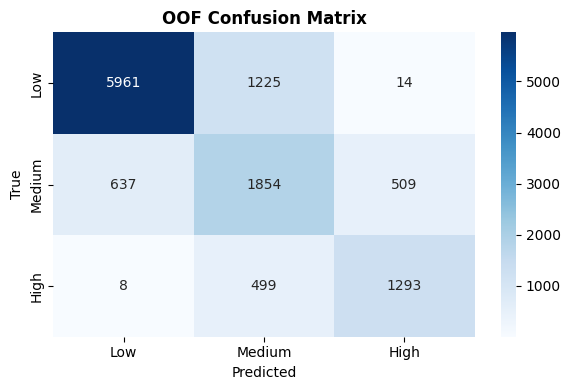

In [88]:
print("\nOOF Classification Report:")
print(classification_report(y, oof, target_names=["Low Risk","Medium Risk","High Risk"]))

# Confusion matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y, oof)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.title("OOF Confusion Matrix", fontweight="bold")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()


# Per-class metrics bar chart

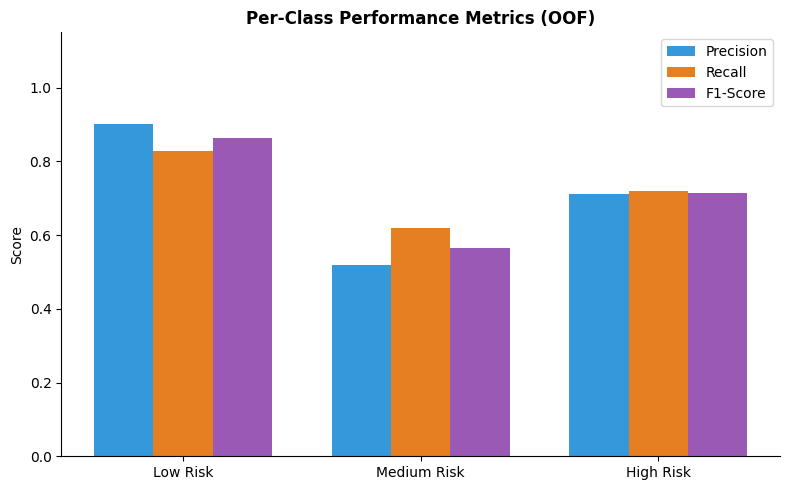

In [89]:
prec = precision_score(y, oof, average=None)
rec  = recall_score(y, oof, average=None)
f1s  = f1_score(y, oof, average=None)
x = np.arange(3); w = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x-w, prec, w, label="Precision", color="#3498db")
plt.bar(x,   rec,  w, label="Recall",    color="#e67e22")
plt.bar(x+w, f1s,  w, label="F1-Score",  color="#9b59b6")
plt.xticks(x, ["Low Risk","Medium Risk","High Risk"])
plt.ylim(0, 1.15); plt.ylabel("Score")
plt.title("Per-Class Performance Metrics (OOF)", fontweight="bold")
plt.legend(); sns.despine(); plt.tight_layout(); plt.show()

# Feature Importance

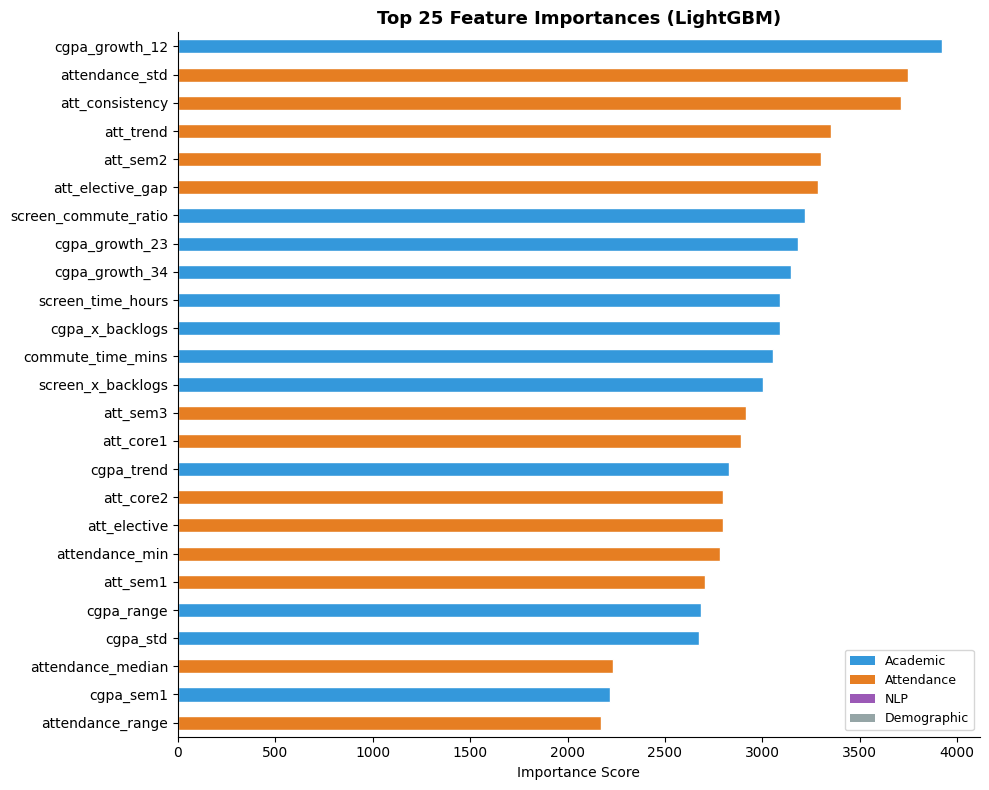

In [90]:
lgbm_fi = LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=63,
                          subsample=0.8, colsample_bytree=0.8,
                          class_weight="balanced", random_state=42, verbose=-1)
lgbm_fi.fit(X, y)

feat_imp = pd.Series(lgbm_fi.feature_importances_, index=X.columns).nlargest(25).sort_values()

bar_colors = []
for name in feat_imp.index:
    if any(k in name for k in ["cgpa","backlog","screen","commute","scholarship","part_time","working","job","log_"]):
        bar_colors.append("#3498db")
    elif any(k in name for k in ["att_","attendance","core","elective","sem"]):
        bar_colors.append("#e67e22")
    elif any(k in name for k in ["tfidf_","sent_","high_risk","positive","kw_","note_","word_"]):
        bar_colors.append("#9b59b6")
    else:
        bar_colors.append("#95a5a6")

from matplotlib.patches import Patch
plt.figure(figsize=(10, 8))
feat_imp.plot(kind="barh", color=bar_colors, edgecolor="white")
plt.title("Top 25 Feature Importances (LightGBM)", fontweight="bold", fontsize=13)
plt.xlabel("Importance Score")
plt.legend(handles=[
    Patch(facecolor="#3498db", label="Academic"),
    Patch(facecolor="#e67e22", label="Attendance"),
    Patch(facecolor="#9b59b6", label="NLP"),
    Patch(facecolor="#95a5a6", label="Demographic"),
], loc="lower right", fontsize=9)
sns.despine(); plt.tight_layout(); plt.show()

# Submission

In [92]:
final_preds = np.argmax(test_preds, axis=1)

submission = pd.DataFrame({
    "student_id"   : test_final["student_id"].values,
    "dropout_risk" : final_preds
})

In [95]:
print(f"\nSubmission shape    : {submission.shape}")
print(f"Sample sub shape    : {sample_sub.shape}")
print(f"Prediction distribution:\n{pd.Series(final_preds).value_counts().sort_index()}")
print(submission.head(10))

submission.to_csv("/kaggle/working/submission.csv", index=False)
print("\nsaved → /kaggle/working/submission.csv")


Submission shape    : (3000, 2)
Sample sub shape    : (3000, 2)
Prediction distribution:
0    1654
1     898
2     448
Name: count, dtype: int64
  student_id  dropout_risk
0   STU03679             0
1   STU11070             0
2   STU13561             2
3   STU00061             1
4   STU02416             1
5   STU14493             0
6   STU14070             2
7   STU12038             0
8   STU13254             0
9   STU12397             0

saved → /kaggle/working/submission.csv
